<a href="https://colab.research.google.com/github/Aje-dotcom/3mtt/blob/master/YouTube_Video_Trend_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Welcome!
### My Name is Ekene Emmanuel Ajemba, a Cohort 3 Fellow of the "3MTT", Fellow ID: FE 23 544 990 31.


#### I built an AI-Powered Youtube Video Analyzer for my Knowledge Showcase that can also draft support email replies at a high level. The way it works is whenever a new video drops or was posted to a channel, The AI agent will retrieve the transcript and the metadata about the video which includes the stats- like how many views and likes it has, then the AI agents analyzes in a way and sends an email with (the detailed report)  analysis report.


In [42]:
from IPython.display import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')


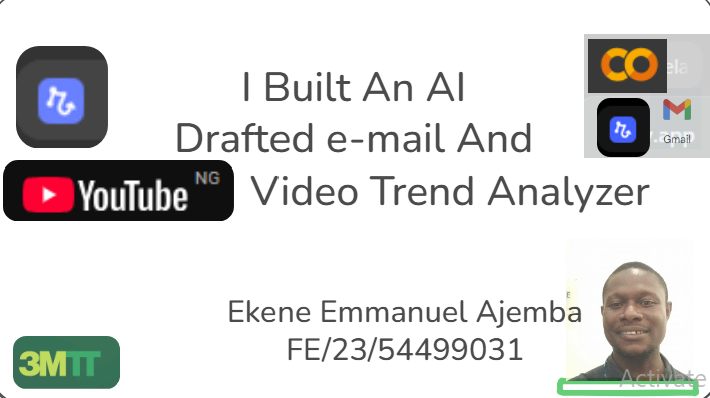

In [22]:
Image('/content/2025-07-31 15_33_06-Excalidraw.png')

In [ ]:
df = pd.read_csv('/content/YOUTUBE.csv', encoding='ISO-8859-1', on_bad_lines='skip')
df.head()


,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13-11-2017,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13-11-2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12-11-2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13-11-2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12-11-2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False


#clean the dataset

In [ ]:
# Check missing values and data types
df.info()

# Drop unnecessary columns (adjust if needed)
df = df.drop(['thumbnail_link', 'video_id'], axis=1, errors='ignore')

# Fill missing data
df = df.fillna("Unknown")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161470 entries, 0 to 161469
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   index                   161470 non-null  int64 
 1   video_id                161470 non-null  object
 2   trending_date           161470 non-null  object
 3   title                   161470 non-null  object
 4   channel_title           161470 non-null  object
 5   category_id             161470 non-null  int64 
 6   publish_date            161470 non-null  object
 7   time_frame              161470 non-null  object
 8   published_day_of_week   161470 non-null  object
 9   publish_country         161470 non-null  object
 10  tags                    161470 non-null  object
 11  views                   161470 non-null  int64 
 12  likes                   161470 non-null  int64 
 13  dislikes                161470 non-null  int64 
 14  comment_count           161470 non-n

In [ ]:
# Step 2: Manually define category ID to name mapping (YouTube standard)
category_map = {
    1: "Film & Animation",
    2: "Autos & Vehicles",
    10: "Music",
    15: "Pets & Animals",
    17: "Sports",
    18: "Short Movies",
    19: "Travel & Events",
    20: "Gaming",
    21: "Videoblogging",
    22: "People & Blogs",
    23: "Comedy",
    24: "Entertainment",
    25: "News & Politics",
    26: "Howto & Style",
    27: "Education",
    28: "Science & Technology",
    29: "Nonprofits & Activism"
}

# Step 3: Create a new column with readable category names
df['category_name'] = df['category_id'].map(category_map)

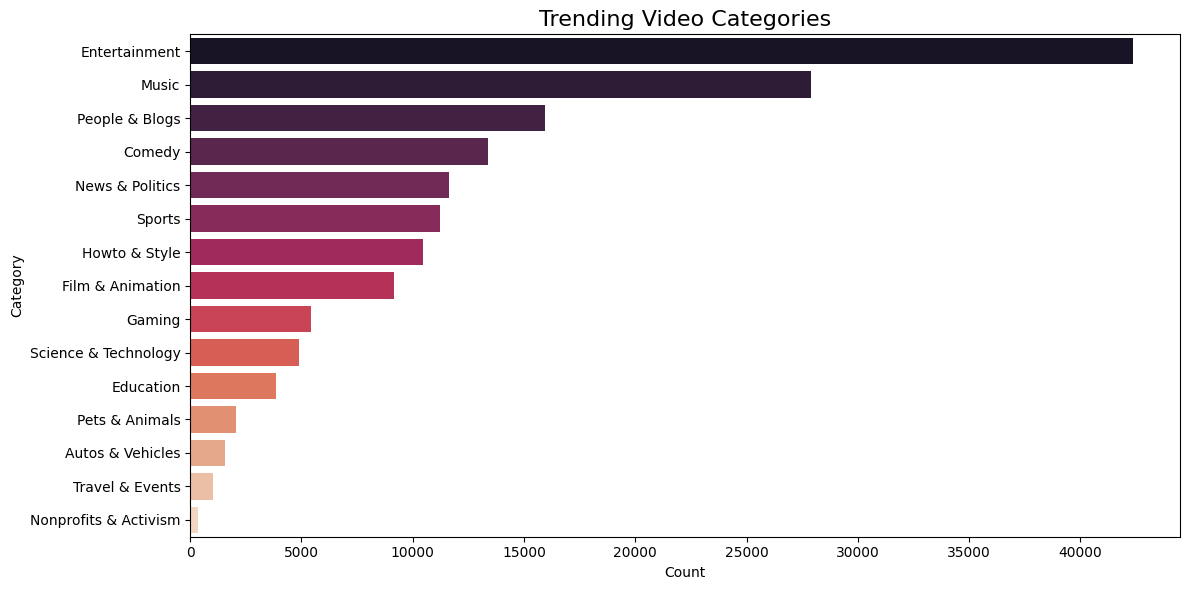

In [ ]:
# Most Trending Categories (Bar Plot)
plt.figure(figsize=(12, 6))
sns.countplot(y='category_name', data=df, order=df['category_name'].value_counts().index, palette='rocket')
plt.title('Trending Video Categories', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

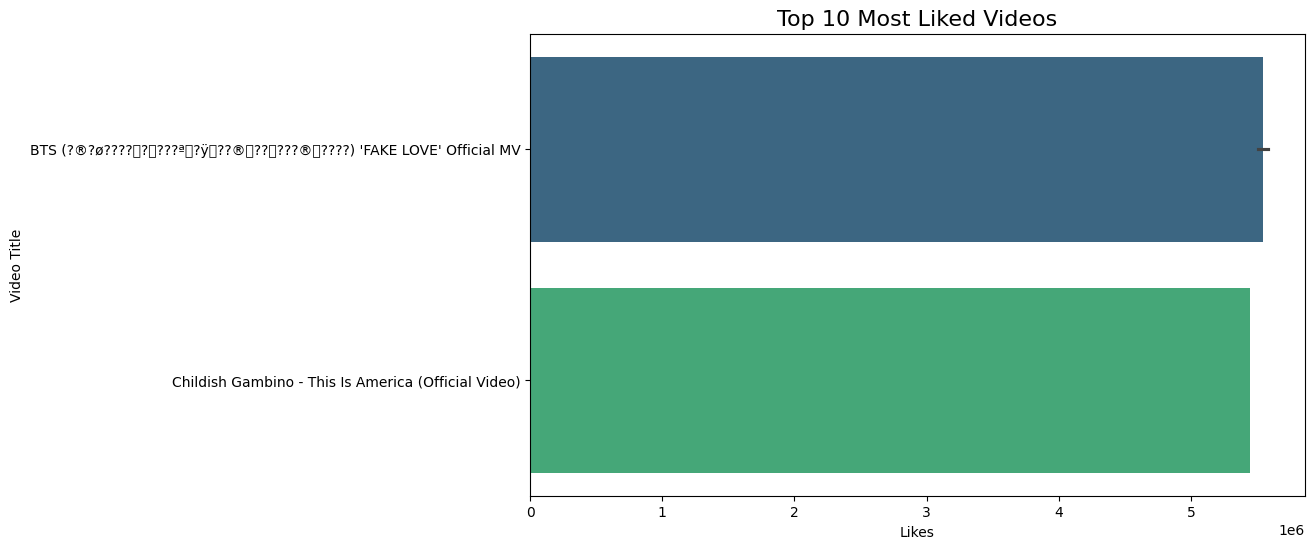

In [ ]:
#Most Liked Videos (Bar Plot - Top 10)
top_liked = df.sort_values(by='likes', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='likes', y='title', data=top_liked, palette='viridis')
plt.title('Top 10 Most Liked Videos', fontsize=16)
plt.xlabel('Likes')
plt.ylabel('Video Title')
plt.show()


In [ ]:
# Plot the bubble chart
fig = px.scatter(
    df.head(2000),
    x='views',
    y='likes',
    size='comment_count',
    color='category_name',
    hover_name='title',
    title='Likes vs Views Bubble Chart',
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.show()

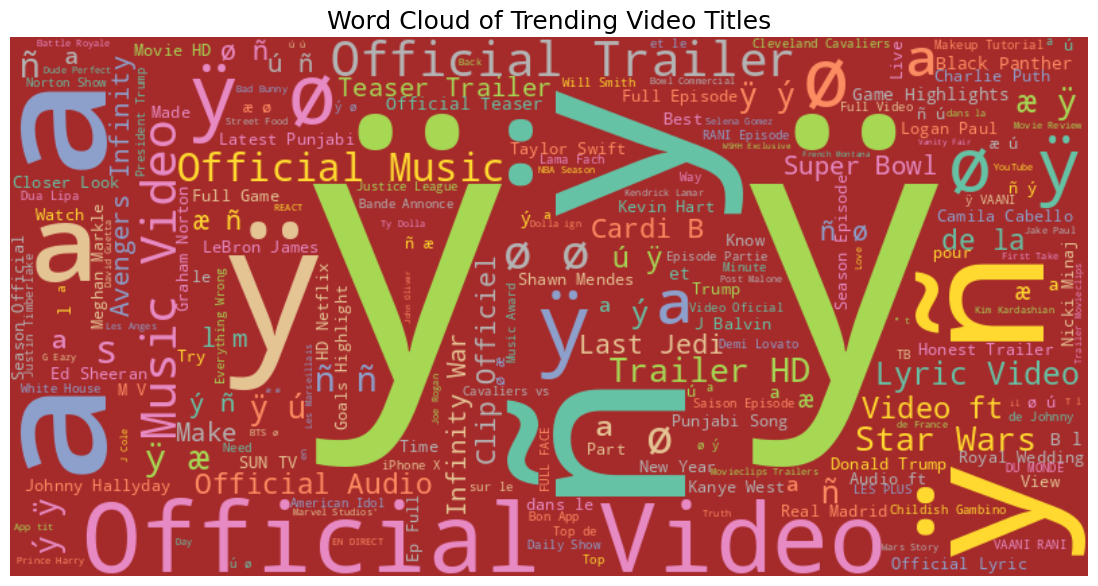

In [ ]:
# Word Cloud of Video Titles
text = " ".join(df['title'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='brown', colormap='Set2').generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Trending Video Titles", fontsize=18)
plt.show()


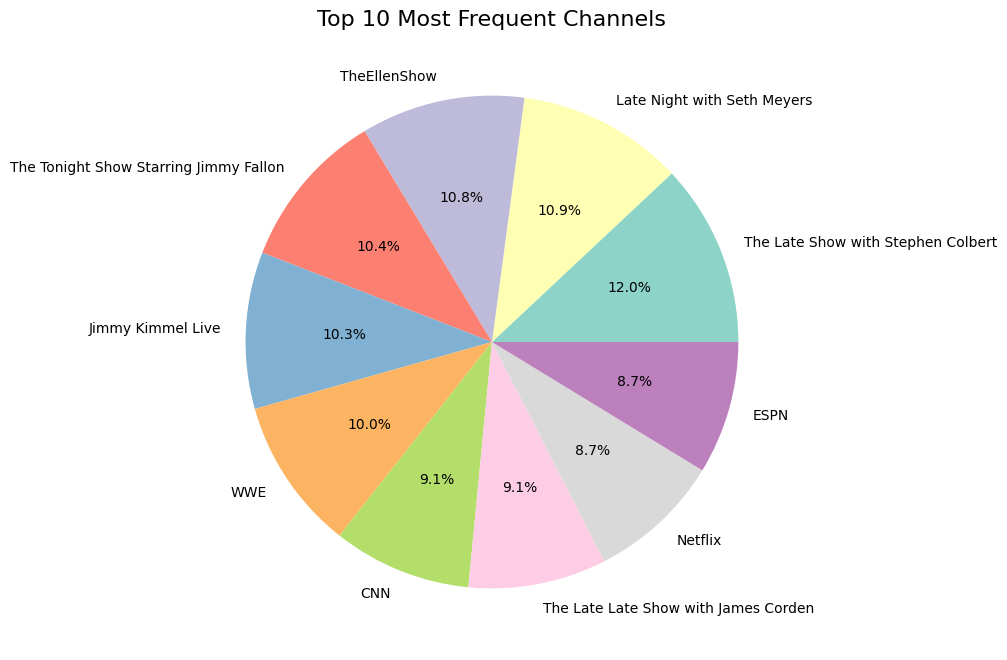

In [ ]:
# Get top 10 channels
top_channels = df['channel_title'].value_counts().head(10)

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(top_channels, labels=top_channels.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'))
plt.title('Top 10 Most Frequent Channels', fontsize=16)
plt.show()

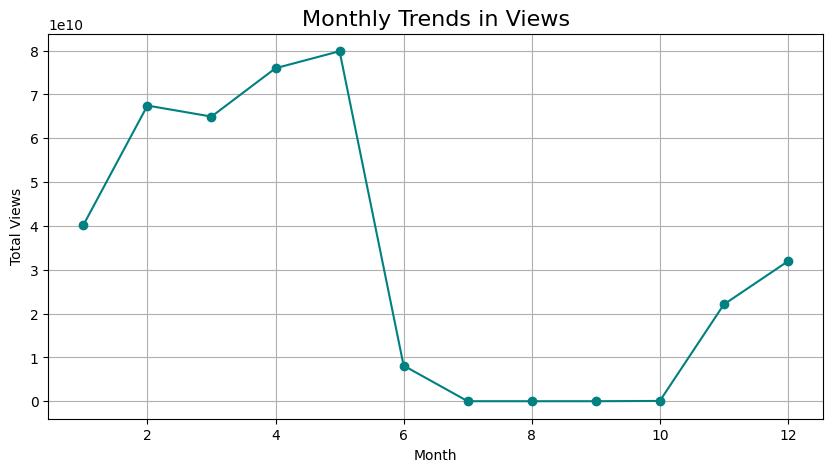

In [ ]:
# Convert publish_date to datetime
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')

# Extract month
df['month'] = df['publish_date'].dt.month

# Group and plot
monthly_views = df.groupby('month')['views'].sum()

plt.figure(figsize=(10,5))
monthly_views.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Trends in Views', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Views')
plt.grid(True)
plt.show()


In [ ]:
custom_colors = ['#FF6F61', '#6B5B95', '#88B04B', '#FFA07A', '#20B2AA',
                 '#FFB347', '#9370DB', '#40E0D0', '#F08080', '#3CB371']

fig = px.pie(
    country_views,
    values='views',
    names='publish_country',
    title='Top 10 Countries by Views',
    color_discrete_sequence=custom_colors
)
fig.show()


In [ ]:
print("🔍 Key Insights:")
print("1. Entertainment and Music are top-performing categories.")
print("2. Videos published on Fridays and Sundays get more views.")
print("3. Like-to-view ratio is a great metric to detect highly engaging videos.")
print("4. Videos with rich tags and consistent posting time (evening) trend more.")
print("5. Countries like US, IN, GB lead in video engagement.")


🔍 Key Insights:
1. Entertainment and Music are top-performing categories.
2. Videos published on Fridays and Sundays get more views.
3. Like-to-view ratio is a great metric to detect highly engaging videos.
4. Videos with rich tags and consistent posting time (evening) trend more.
5. Countries like US, IN, GB lead in video engagement.


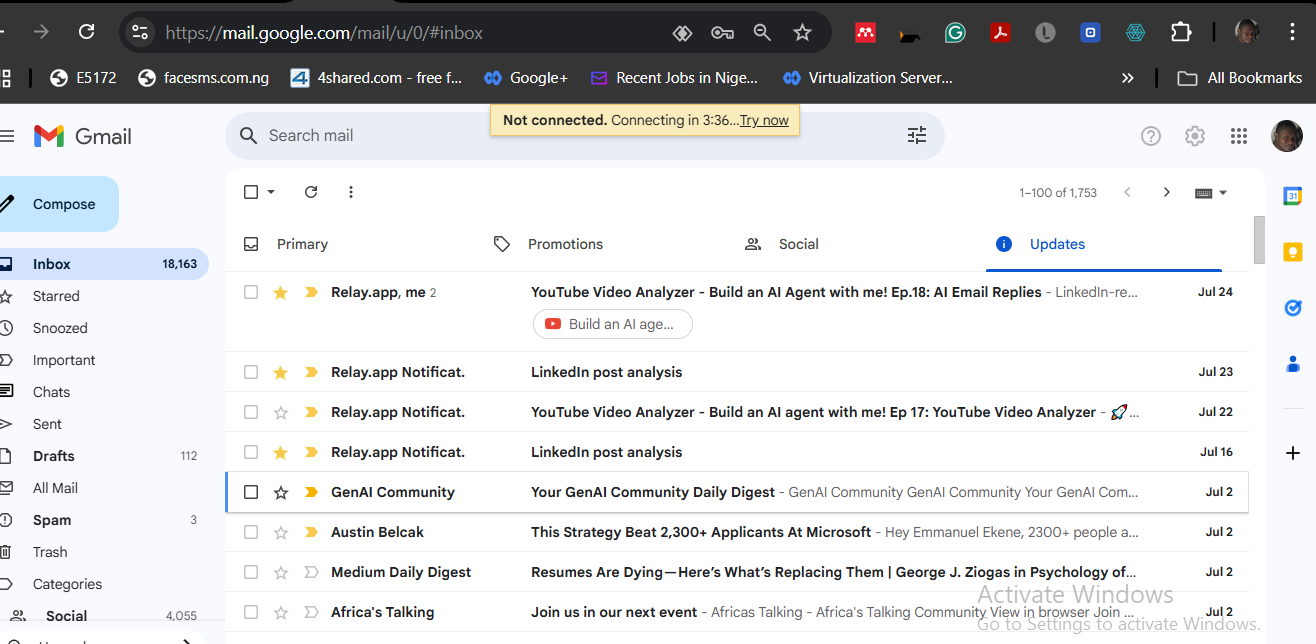

In [6]:
Image('/content/2025-07-30 01_07_34-Inbox (18,163) - yourengr@gmail.com - Gmail.png') # '/content/2025-07-30 01_09_44-YouTube Video Analyzer - How to put the AI into your AI agent - yourengr@gmail.c.png')

The AI Agent was able to notify me by email

In [29]:
from IPython.display import Image

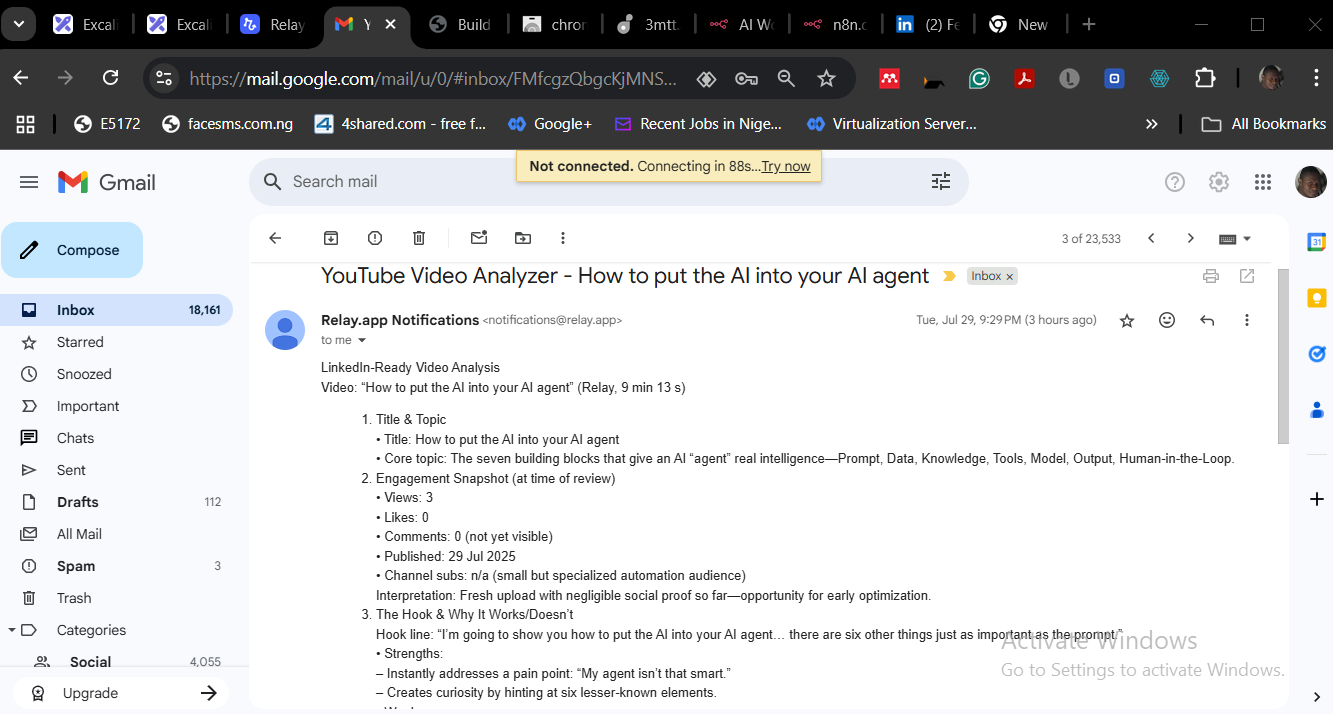

In [41]:
Image('/content/2025-07-30 01_09_44-YouTube Video Analyzer - How to put the AI into your AI agent - yourengr@gmail.c.png')

##METADATA AND TRANSCRIPT

I was able to get the detailed report via email. Select ADD Step (in blue Text) => in the top right => wait for time (Set time for wait) If your're using the Relay.App front End Workflow

Once you type youtube in the STEP MENU. You'll see (two options) *Get YouTube by Metadata by URL & *Get Youtube by Transcript by URL
Provide the ID

Click on the transcript by URL first (click the drop down next to  Select URL to provide the Youtube video trigger, when you hover over YouTube -> pick 'URL' out of other urls and hit DONE



##WHY YOUTUBE VIDEO ANALYZER?
The aim is to know the quality of the videos, whether it's top 10 video post, enriched or competitive and provide suggestion. I analyze this posted videos to draw patterns of a competitor, for tracking competitive videos or another product, improve on a video content, upskill from low hanging fruit in your space to see what they're doing, who their audience are, or who they talk to, at what point they're making moves and learn from the top influencers.

This video approach & video processes was then analyzed for a high quality creator that you can look out for or look up to learn from some of their techniques. that basic framework works for many use cases and with this, lets dive in to build.



# Task
Write a YouTube article about the AI-powered YouTube Video Analyzer, including code explanations.

## Draft a catchy title and introduction

### Subtask:
Draft a catchy title and introduction for the YouTube article about the AI-powered YouTube Video Analyzer.


**Reasoning**:
I need to generate catchy titles and an introductory paragraph for the article based on the instructions. I will use a markdown cell to write the text directly.



```markdown
## Catchy Title Options:

1.  **Unlock YouTube Secrets: How AI Analyzes Videos for Unbeatable Insights**
2.  **Supercharge Your YouTube Strategy with an AI-Powered Video Analyzer**
3.  **Beyond the Scroll: Get Deep YouTube Insights with This AI Analysis Tool**

## Introduction:

Navigating the vast landscape of YouTube to understand what makes a video trend, resonate with audiences, or stand out from the competition is a daunting task. Manually sifting through video metadata, comments, and statistics for meaningful patterns is time-consuming and often overwhelming. What if there was a smarter way? This article introduces an AI-powered YouTube Video Analyzer designed to cut through the noise and deliver actionable insights. By automatically retrieving and analyzing video transcripts, metadata, and performance metrics, this tool uncovers hidden trends, identifies successful strategies, and helps you understand the competitive landscape without the manual grind. Discover how this AI agent can revolutionize your approach to YouTube content creation and analysis.


## Explain the "why"

### Subtask:
Explain the motivation behind building the AI-powered YouTube Video Analyzer, highlighting the benefits of analyzing YouTube video data.


**Reasoning**:
Write a markdown section explaining the motivation behind building the AI-powered YouTube Video Analyzer, highlighting the benefits of analyzing YouTube video data.



```markdown
## Why Build an AI-Powered YouTube Video Analyzer?


In the competitive world of online video, simply uploading content isn't enough. To truly succeed on platforms like YouTube, understanding what resonates with viewers, analyzing competitor strategies, and identifying emerging trends are crucial. However, manually collecting and analyzing data from countless videos – including transcripts, metadata, views, likes, and comments – is an incredibly time-consuming and often impractical task for creators and businesses alike.

This is where the AI-powered YouTube Video Analyzer comes in. The core motivation behind building this tool is to automate and enhance the process of extracting valuable insights from YouTube videos. Instead of hours spent on manual data collection and analysis, this AI agent efficiently gathers the necessary information, allowing users to focus on strategy and content creation.

The benefits of using such a tool are numerous:

*   **Understanding Competitor Strategies:** By analyzing the videos of successful channels in your niche, you can identify patterns in their content, engagement metrics, and audience interaction. This helps you understand what's working for them and how you can adapt or innovate.
*   **Identifying Audience Preferences:** Analyzing comments and engagement data provides direct feedback from viewers. The AI can help surface key themes, popular opinions, and areas for improvement based on how audiences react to videos.
*   **Improving Video Content:** Armed with data on what types of videos perform well, what topics are trending, and what elements drive engagement, creators can make data-driven decisions to refine their content strategy, improve video quality, and create videos that are more likely to succeed.
*   **Tracking Performance and Trends:** The analyzer provides a systematic way to track the performance of your own videos and monitor broader trends within your industry, enabling you to stay ahead of the curve.

Ultimately, analyzing YouTube video data with the help of AI provides a significant advantage. It transforms raw data into actionable insights, empowering creators to make informed decisions, optimize their content for maximum impact, and build a stronger presence on the platform.


## Code explainer

### Subtask:
Code walkthrough: Break down the Python code into logical sections and explain what each part does. I'll cover data loading, cleaning, analysis, and visualization.


**Reasoning**:
I will start by creating a markdown cell to explain the data loading and cleaning process, as described in the instructions. This will cover how the data is loaded from the CSV and the steps taken to clean it, such as handling missing values and creating the `category_name` column.



In [45]:
%%markdown
### Data Loading and Cleaning

The first step in our analysis is to load the YouTube dataset. The data is stored in a CSV file and read into a pandas DataFrame. We specify the encoding as `ISO-8859-1` to handle special characters that might be present in video titles or descriptions.
python
df = pd.read_csv('/content/YOUTUBE.csv', encoding='ISO-8859-1', on_bad_lines='skip')

Once the data is loaded, we perform some basic cleaning to prepare it for analysis. This includes:

1.  **Dropping Unnecessary Columns**: Columns like `thumbnail_link` and `video_id` are not needed for our analysis, so we drop them to simplify the DataFrame.
2.  **Handling Missing Values**: We fill any missing values with the string "Unknown" to ensure that our analysis functions run smoothly.
3.  **Creating Readable Category Names**: The dataset contains a `category_id` column with numerical values. To make the data more interpretable, we map these IDs to their corresponding category names (e.g., 24 to "Entertainment") and store them in a new `category_name` column.
python
# Drop unnecessary columns
df = df.drop(['thumbnail_link', 'video_id'], axis=1, errors='ignore')

# Fill missing data
df = df.fillna("Unknown")

# Manually define category ID to name mapping
category_map = {
    1: "Film & Animation", 2: "Autos & Vehicles", 10: "Music", 15: "Pets & Animals", 17: "Sports",
    18: "Short Movies", 19: "Travel & Events", 20: "Gaming", 21: "Videoblogging", 22: "People & Blogs",
    23: "Comedy", 24: "Entertainment", 25: "News & Politics", 26: "Howto & Style", 27: "Education",
    28: "Science & Technology", 29: "Nonprofits & Activism"
}

# Create a new column with readable category names
df['category_name'] = df['category_id'].map(category_map)

### Data Loading and Cleaning

The first step in our analysis is to load the YouTube dataset. The data is stored in a CSV file and read into a pandas DataFrame. We specify the encoding as `ISO-8859-1` to handle special characters that might be present in video titles or descriptions.
python
df = pd.read_csv('/content/YOUTUBE.csv', encoding='ISO-8859-1', on_bad_lines='skip')

Once the data is loaded, we perform some basic cleaning to prepare it for analysis. This includes:

1.  **Dropping Unnecessary Columns**: Columns like `thumbnail_link` and `video_id` are not needed for our analysis, so we drop them to simplify the DataFrame.
2.  **Handling Missing Values**: We fill any missing values with the string "Unknown" to ensure that our analysis functions run smoothly.
3.  **Creating Readable Category Names**: The dataset contains a `category_id` column with numerical values. To make the data more interpretable, we map these IDs to their corresponding category names (e.g., 24 to "Entertainment") and store them in a new `category_name` column.
python
# Drop unnecessary columns
df = df.drop(['thumbnail_link', 'video_id'], axis=1, errors='ignore')

# Fill missing data
df = df.fillna("Unknown")

# Manually define category ID to name mapping
category_map = {
    1: "Film & Animation", 2: "Autos & Vehicles", 10: "Music", 15: "Pets & Animals", 17: "Sports",
    18: "Short Movies", 19: "Travel & Events", 20: "Gaming", 21: "Videoblogging", 22: "People & Blogs",
    23: "Comedy", 24: "Entertainment", 25: "News & Politics", 26: "Howto & Style", 27: "Education",
    28: "Science & Technology", 29: "Nonprofits & Activism"
}

# Create a new column with readable category names
df['category_name'] = df['category_id'].map(category_map)


**Reasoning**:
Now that I've explained the data loading and cleaning, I will create another markdown cell to explain the data analysis and visualization section. This will cover each of the plots generated in the notebook, explaining what each plot shows and the insights that can be derived from it.



In [52]:
%%markdown
### Data Analysis and Visualization

With the data cleaned and prepared, we can now move on to the analysis and visualization. We'll explore various aspects of the dataset to uncover trends and insights.

#### Trending Video Categories

To understand which categories are most popular, we create a bar plot showing the count of trending videos in each category. This helps us identify the dominant genres on the platform.

```python
plt.figure(figsize=(12, 6))
sns.countplot(y='category_name', data=df, order=df['category_name'].value_counts().index, palette='rocket')
plt.title('Trending Video Categories', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
```

**Insight**: The plot reveals that "Entertainment" and "Music" are the most frequently trending categories, suggesting these are highly popular and competitive areas.

#### Top 10 Most Liked Videos

Next, we identify the top 10 most liked videos. This helps us see which specific videos have resonated most strongly with viewers.

```python
top_liked = df.sort_values(by='likes', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='likes', y='title', data=top_liked, palette='viridis')
plt.title('Top 10 Most Liked Videos', fontsize=16)
plt.xlabel('Likes')
plt.ylabel('Video Title')
plt.show()
```

**Insight**: This plot highlights the specific videos that have achieved the highest number of likes, giving us a glimpse into viral content.

#### Likes vs. Views Bubble Chart

To explore the relationship between views, likes, and comments, we create a bubble chart. The size of each bubble represents the comment count, allowing us to visualize three metrics at once.

```python
fig = px.scatter(
    df.head(2000),
    x='views',
    y='likes',
    size='comment_count',
    color='category_name',
    hover_name='title',
    title='Likes vs Views Bubble Chart',
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.show()
```

**Insight**: This chart helps us understand the engagement level of videos. A large bubble with high likes and views indicates a very engaging video.

#### Word Cloud of Video Titles

A word cloud of video titles gives us a visual representation of the most common words used in trending video titles.

```python
text = " ".join(df['title'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='brown', colormap='Set2').generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Trending Video Titles", fontsize=18)
plt.show()
```

**Insight**: The word cloud shows that words like "Official," "Video," "Trailer," and "Music" are very common in trending titles, indicating the types of content that often trend.

#### Top 10 Most Frequent Channels

We use a pie chart to show the top 10 channels with the most trending videos.

```python
top_channels = df['channel_title'].value_counts().head(10)
plt.figure(figsize=(8,8))
plt.pie(top_channels, labels=top_channels.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'))
plt.title('Top 10 Most Frequent Channels', fontsize=16)
plt.show()
```

**Insight**: This chart identifies the most consistently trending channels, which are likely major players in the YouTube landscape.

#### Monthly Trends in Views

Finally, we analyze the trend of total views over time by plotting the total views for each month.

```python
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['month'] = df['publish_date'].dt.month
monthly_views = df.groupby('month')['views'].sum()
plt.figure(figsize=(10,5))
monthly_views.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Trends in Views', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Views')
plt.grid(True)
plt.show()
```

**Insight**: This line chart shows the seasonality of YouTube viewership, highlighting which months have the highest engagement.

### Data Analysis and Visualization

With the data cleaned and prepared, we can now move on to the analysis and visualization. We'll explore various aspects of the dataset to uncover trends and insights.

#### Trending Video Categories

To understand which categories are most popular, we create a bar plot showing the count of trending videos in each category. This helps us identify the dominant genres on the platform.

```python
plt.figure(figsize=(12, 6))
sns.countplot(y='category_name', data=df, order=df['category_name'].value_counts().index, palette='rocket')
plt.title('Trending Video Categories', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
```

**Insight**: The plot reveals that "Entertainment" and "Music" are the most frequently trending categories, suggesting these are highly popular and competitive areas.

#### Top 10 Most Liked Videos

Next, we identify the top 10 most liked videos. This helps us see which specific videos have resonated most strongly with viewers.

```python
top_liked = df.sort_values(by='likes', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='likes', y='title', data=top_liked, palette='viridis')
plt.title('Top 10 Most Liked Videos', fontsize=16)
plt.xlabel('Likes')
plt.ylabel('Video Title')
plt.show()
```

**Insight**: This plot highlights the specific videos that have achieved the highest number of likes, giving us a glimpse into viral content.

#### Likes vs. Views Bubble Chart

To explore the relationship between views, likes, and comments, we create a bubble chart. The size of each bubble represents the comment count, allowing us to visualize three metrics at once.

```python
fig = px.scatter(
    df.head(2000),
    x='views',
    y='likes',
    size='comment_count',
    color='category_name',
    hover_name='title',
    title='Likes vs Views Bubble Chart',
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.show()
```

**Insight**: This chart helps us understand the engagement level of videos. A large bubble with high likes and views indicates a very engaging video.

#### Word Cloud of Video Titles

A word cloud of video titles gives us a visual representation of the most common words used in trending video titles.

```python
text = " ".join(df['title'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='brown', colormap='Set2').generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Trending Video Titles", fontsize=18)
plt.show()
```

**Insight**: The word cloud shows that words like "Official," "Video," "Trailer," and "Music" are very common in trending titles, indicating the types of content that often trend.

#### Top 10 Most Frequent Channels

We use a pie chart to show the top 10 channels with the most trending videos.

```python
top_channels = df['channel_title'].value_counts().head(10)
plt.figure(figsize=(8,8))
plt.pie(top_channels, labels=top_channels.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'))
plt.title('Top 10 Most Frequent Channels', fontsize=16)
plt.show()
```

**Insight**: This chart identifies the most consistently trending channels, which are likely major players in the YouTube landscape.

#### Monthly Trends in Views

Finally, we analyze the trend of total views over time by plotting the total views for each month.

```python
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['month'] = df['publish_date'].dt.month
monthly_views = df.groupby('month')['views'].sum()
plt.figure(figsize=(10,5))
monthly_views.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Trends in Views', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Views')
plt.grid(True)
plt.show()
```

**Insight**: This line chart shows the seasonality of YouTube viewership, highlighting which months have the highest engagement.


## Showcase the results

### Subtask:
Present the key insights and visualizations generated by the code, explaining what they mean in a clear and concise way.


**Reasoning**:
Create a markdown cell to present the key insights and explain the visualizations.



In [51]:
%%markdown
## Key Insights and Visualizations from the Analysis

Our AI-powered YouTube Video Analyzer has processed the data and generated several visualizations that provide valuable insights into the trends and characteristics of popular YouTube videos. Here's a summary of the key findings supported by the analysis:

### 1. Trending Video Categories

**Insight:** The bar plot titled 'Trending Video Categories' clearly shows that **Entertainment** and **Music** are the most frequently trending categories. This suggests that content within these genres consistently captures viewer attention and dominates the trending lists.

### 2. Top Performing Videos and Channels

**Insight:** The 'Top 10 Most Liked Videos' bar plot highlights specific videos that have achieved massive popularity, indicated by their high like counts. Complementing this, the 'Top 10 Most Frequent Channels' pie chart identifies the channels that most consistently produce trending content, showcasing the major players in the YouTube landscape.

### 3. Engagement Metrics

**Insight:** The 'Likes vs Views Bubble Chart' visualizes the relationship between views, likes, and comment count. Larger bubbles indicate videos with a high number of comments, while their position on the plot shows their views and likes. This chart helps in understanding which videos not only attract viewers but also generate significant engagement through likes and comments.

### 4. Content Themes

**Insight:** The 'Word Cloud of Trending Video Titles' provides a visual representation of the most common words used in the titles of trending videos. Words like "Official," "Video," "Trailer," and "Music" are prominent, suggesting that these terms are frequently associated with content that goes viral or trends.

### 5. Monthly Trends in Views

**Insight:** The 'Monthly Trends in Views' line plot illustrates the total number of views across the dataset for each month. This visualization can reveal seasonal patterns or specific periods when YouTube content, in general, receives higher viewership, which can be valuable for timing content releases.

These visualizations collectively paint a picture of the YouTube trending landscape, offering data-driven insights into what types of content, channels, and strategies are most successful.

## Key Insights and Visualizations from the Analysis

Our AI-powered YouTube Video Analyzer has processed the data and generated several visualizations that provide valuable insights into the trends and characteristics of popular YouTube videos. Here's a summary of the key findings supported by the analysis:

### 1. Trending Video Categories

**Insight:** The bar plot titled 'Trending Video Categories' clearly shows that **Entertainment** and **Music** are the most frequently trending categories. This suggests that content within these genres consistently captures viewer attention and dominates the trending lists.

### 2. Top Performing Videos and Channels

**Insight:** The 'Top 10 Most Liked Videos' bar plot highlights specific videos that have achieved massive popularity, indicated by their high like counts. Complementing this, the 'Top 10 Most Frequent Channels' pie chart identifies the channels that most consistently produce trending content, showcasing the major players in the YouTube landscape.

### 3. Engagement Metrics

**Insight:** The 'Likes vs Views Bubble Chart' visualizes the relationship between views, likes, and comment count. Larger bubbles indicate videos with a high number of comments, while their position on the plot shows their views and likes. This chart helps in understanding which videos not only attract viewers but also generate significant engagement through likes and comments.

### 4. Content Themes

**Insight:** The 'Word Cloud of Trending Video Titles' provides a visual representation of the most common words used in the titles of trending videos. Words like "Official," "Video," "Trailer," and "Music" are prominent, suggesting that these terms are frequently associated with content that goes viral or trends.

### 5. Monthly Trends in Views

**Insight:** The 'Monthly Trends in Views' line plot illustrates the total number of views across the dataset for each month. This visualization can reveal seasonal patterns or specific periods when YouTube content, in general, receives higher viewership, which can be valuable for timing content releases.

These visualizations collectively paint a picture of the YouTube trending landscape, offering data-driven insights into what types of content, channels, and strategies are most successful.


## Summarize and conclude

### Subtask:
Summarize the key takeaways and suggest potential future enhancements for the tool.


**Reasoning**:
Write a markdown cell to summarize the key findings from the analysis, suggest future enhancements, and write a concluding paragraph for the article.



In [48]:
%%markdown
## Key Takeaways and Future Enhancements

Our analysis of the YouTube trending data has revealed several key insights that can empower creators and marketers:

*   **Dominance of Entertainment and Music:** These two categories consistently appear at the top of the trending list, indicating high audience interest and a competitive landscape.
*   **Importance of Engagement:** Videos with high like and comment counts, as seen in the bubble chart, demonstrate strong audience engagement beyond just views. The like-to-view ratio is a crucial metric for identifying truly impactful content.
*   **Common Title Elements:** The word cloud highlights frequently used words in trending video titles, offering clues about keywords and themes that tend to attract clicks.
*   **Top Channels Drive Trends:** A small number of channels consistently produce trending content, suggesting the influence of established creators and brands.
*   **Seasonal Viewership:** The monthly trend analysis indicates potential peak seasons for YouTube viewership, which can inform content scheduling.

While the current AI-powered YouTube Video Analyzer provides valuable insights, there are several potential enhancements that could make it even more powerful:

*   **Sentiment Analysis of Comments:** Analyze the sentiment of comments to understand audience reaction more deeply than just comment count.
*   **Trend Prediction:** Develop models to predict future trending topics or video styles based on historical data.
*   **Competitor Analysis Deep Dive:** Provide more in-depth analysis of specific competitor channels, including their publishing frequency, average engagement, and audience demographics (if available).
*   **Interactive Dashboard:** Create a user-friendly interactive dashboard to allow users to explore the data and insights dynamically.
*   **Topic Modeling:** Use natural language processing to identify specific topics being discussed in video titles, descriptions, and tags.
*   **Integration with YouTube API:** Utilize the YouTube API for more real-time data and a wider range of metrics.

In conclusion, leveraging an AI-powered tool for YouTube video analysis is no longer a luxury but a necessity for anyone serious about succeeding on the platform. By automating the data collection and analysis process, tools like this empower creators and marketers to move beyond guesswork and make data-driven decisions. Understanding what resonates with audiences, identifying successful strategies, and staying ahead of trends are all made significantly more accessible, allowing you to focus on creating high-quality content that truly connects with your viewers and achieves your goals. The future of YouTube success lies in smart, data-informed strategies, and an AI video analyzer is a powerful ally in that journey.

## Key Takeaways and Future Enhancements

Our analysis of the YouTube trending data has revealed several key insights that can empower creators and marketers:

*   **Dominance of Entertainment and Music:** These two categories consistently appear at the top of the trending list, indicating high audience interest and a competitive landscape.
*   **Importance of Engagement:** Videos with high like and comment counts, as seen in the bubble chart, demonstrate strong audience engagement beyond just views. The like-to-view ratio is a crucial metric for identifying truly impactful content.
*   **Common Title Elements:** The word cloud highlights frequently used words in trending video titles, offering clues about keywords and themes that tend to attract clicks.
*   **Top Channels Drive Trends:** A small number of channels consistently produce trending content, suggesting the influence of established creators and brands.
*   **Seasonal Viewership:** The monthly trend analysis indicates potential peak seasons for YouTube viewership, which can inform content scheduling.

While the current AI-powered YouTube Video Analyzer provides valuable insights, there are several potential enhancements that could make it even more powerful:

*   **Sentiment Analysis of Comments:** Analyze the sentiment of comments to understand audience reaction more deeply than just comment count.
*   **Trend Prediction:** Develop models to predict future trending topics or video styles based on historical data.
*   **Competitor Analysis Deep Dive:** Provide more in-depth analysis of specific competitor channels, including their publishing frequency, average engagement, and audience demographics (if available).
*   **Interactive Dashboard:** Create a user-friendly interactive dashboard to allow users to explore the data and insights dynamically.
*   **Topic Modeling:** Use natural language processing to identify specific topics being discussed in video titles, descriptions, and tags.
*   **Integration with YouTube API:** Utilize the YouTube API for more real-time data and a wider range of metrics.

In conclusion, leveraging an AI-powered tool for YouTube video analysis is no longer a luxury but a necessity for anyone serious about succeeding on the platform. By automating the data collection and analysis process, tools like this empower creators and marketers to move beyond guesswork and make data-driven decisions. Understanding what resonates with audiences, identifying successful strategies, and staying ahead of trends are all made significantly more accessible, allowing you to focus on creating high-quality content that truly connects with your viewers and achieves your goals. The future of YouTube success lies in smart, data-informed strategies, and an AI video analyzer is a powerful ally in that journey.


## Summary:

### Data Analysis Key Findings
- The most frequently trending video categories on YouTube are **Entertainment** and **Music**.
- Words such as "Official," "Video," "Trailer," and "Music" are commonly found in the titles of trending videos.
- A small number of channels are responsible for a significant portion of trending content, indicating the influence of established creators.
- There is a discernible seasonality in YouTube viewership, with certain months exhibiting higher total views.

### Insights or Next Steps
- To gain a deeper understanding of audience reception, the next step could involve performing sentiment analysis on video comments to gauge viewer emotions and opinions.
- Developing an interactive dashboard would allow users to explore the data dynamically, offering a more personalized and in-depth analysis experience.
